# Imputation Strategies Comparison

This notebook demonstrates different imputation strategies for handling missing data in the stroke dataset. We compare Mean Imputation (M1) and KNN Imputation (M2), then prepare datasets for modeling.

## 1. Setup and Data Loading

Import required libraries and load the preprocessed stroke dataset. Split data into training (70%) and testing (30%) sets with stratification to preserve class distribution.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
# Nếu muốn dùng MICE: from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer

In [ ]:
# Load data
df = pd.read_csv('../data/processed/stroke_all.csv')

# Tách Feature (X) và Target (y)
X = df.drop(columns=['stroke', 'source'])
y = df['stroke']

# Chia test/Test (70/30) theo kế hoạch
# stratify=y để đảm bảo tỷ lệ đột quỵ ở train và test giống nhau (quan trọng vì data mất cân bằng)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test:  {X_train.shape}")

Kích thước tập Train: (42063, 10)
Kích thước tập Test:  (18028, 10)


## 2. Build Imputation Pipelines (M1 and M2)

Define imputation strategies using Mean Imputation (M1) and KNN Imputation (M2). Separate numeric and categorical columns for appropriate handling.

In [4]:
# Chỉ áp dụng imputation cho các cột số (numeric) bị thiếu (cụ thể là 'bmi')
# Các cột phân loại (categorical) nếu thiếu thì điền 'Unknown' hoặc Mode
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
categorical_cols = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

# Hàm hỗ trợ xử lý Encoding (One-Hot) sơ bộ để chạy được KNN
# (Vì KNN cần tính khoảng cách số học, không tính được trên chữ)
def preprocess_for_imputation(X_data):
    X_encoded = pd.get_dummies(X_data, columns=categorical_cols, drop_first=True)
    return X_encoded

### M1: Simple Mean Imputation

Apply mean imputation to numeric columns. This is the simplest approach but may not capture relationships in the data.

In [5]:
print("--- Đang xử lý M1: Mean Imputation ---")
imputer_mean = SimpleImputer(strategy='mean')

# Chỉ fit trên Train
X_train_m1 = X_train.copy()
X_test_m1 = X_test.copy()

X_train_m1[numeric_cols] = imputer_mean.fit_transform(X_train[numeric_cols])
X_test_m1[numeric_cols] = imputer_mean.transform(X_test[numeric_cols]) # Chỉ transform Test

--- Đang xử lý M1: Mean Imputation ---


### M2: Advanced KNN Imputation

Apply k-Nearest Neighbors imputation which considers relationships between variables. This approach is more sophisticated but computationally expensive for large datasets. Features are one-hot encoded before imputation.

In [6]:
print("--- Đang xử lý M2: KNN Imputation ---")
# Lưu ý: KNN chạy khá lâu nếu data lớn
knn_imputer = KNNImputer(n_neighbors=5)

# Cần encode dữ liệu trước khi đưa vào KNN
X_train_encoded = preprocess_for_imputation(X_train)
X_test_encoded = preprocess_for_imputation(X_test)

# Align columns (đảm bảo cột sau one-hot giống nhau)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Fit KNN trên Train
X_train_m2_vals = knn_imputer.fit_transform(X_train_encoded)
X_test_m2_vals = knn_imputer.transform(X_test_encoded)

# Chuyển về DataFrame (M2 này đã bị One-Hot encoded, dùng luôn cho model sau này)
X_train_m2 = pd.DataFrame(X_train_m2_vals, columns=X_train_encoded.columns)
X_test_m2 = pd.DataFrame(X_test_m2_vals, columns=X_test_encoded.columns)

--- Đang xử lý M2: KNN Imputation ---


## 3. Evaluate Imputation Effectiveness (Visualization)

Compare the distribution of BMI before and after imputation using different methods. This helps visualize how each imputation strategy affects the data distribution.

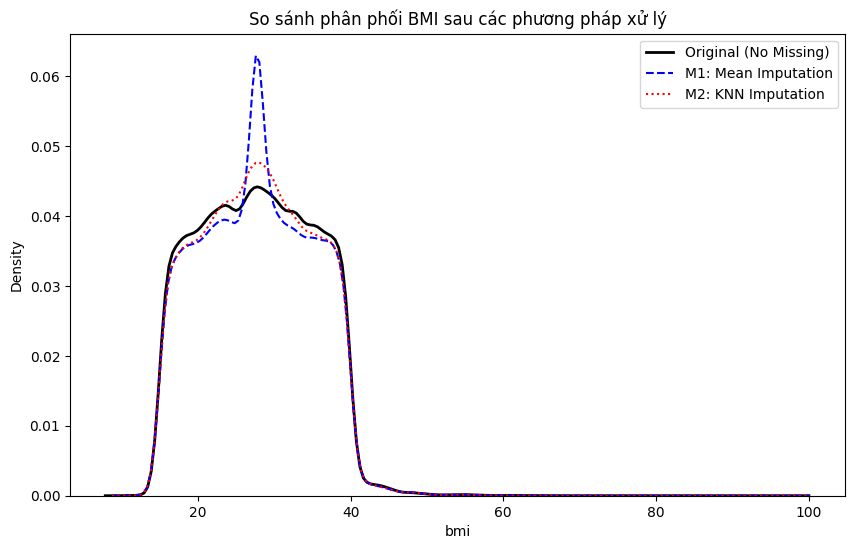

In [7]:
# So sánh phân phối BMI trước và sau khi xử lý

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Phân phối gốc (chỉ lấy phần không null để vẽ)
sns.kdeplot(df['bmi'].dropna(), ax=ax, label='Original (No Missing)', color='black', linewidth=2)

# Phân phối sau M1 (Mean)
sns.kdeplot(X_train_m1['bmi'], ax=ax, label='M1: Mean Imputation', linestyle='--', color='blue')

# Phân phối sau M2 (KNN)
# Lưu ý: Trong X_train_m2, cột bmi vẫn tên là 'bmi' (hoặc cần check lại index cột nếu array)
sns.kdeplot(X_train_m2['bmi'], ax=ax, label='M2: KNN Imputation', linestyle=':', color='red')

plt.title("So sánh phân phối BMI sau các phương pháp xử lý")
plt.legend()
plt.show()

## 4. Save Data for Modeling

Save the imputed datasets in two formats:
- **M1**: Mean imputation with original categorical features (for models that handle categoricals)
- **M2**: KNN imputation with one-hot encoded features (for models requiring numeric features)

In [8]:
# Lưu M1 (Dạng CSV thông thường)
X_train_m1.join(y_train).to_csv('../data/processed/train_M1.csv', index=False)
X_test_m1.join(y_test).to_csv('../data/processed/test_M1.csv', index=False)

# Lưu M2 (Dạng đã One-Hot Encoded)
X_train_m2.join(y_train.reset_index(drop=True)).to_csv('../data/processed/train_M2_knn.csv', index=False)
X_test_m2.join(y_test.reset_index(drop=True)).to_csv('../data/processed/test_M2_knn.csv', index=False)

print("\n✅ Đã lưu các phiên bản dữ liệu M1 và M2 vào folder data/processed/")


✅ Đã lưu các phiên bản dữ liệu M1 và M2 vào folder data/processed/


## 5. Outlier Treatment

Remove outlier from data

### Visuzlization outlier in avg_glucose_level and bmi fields

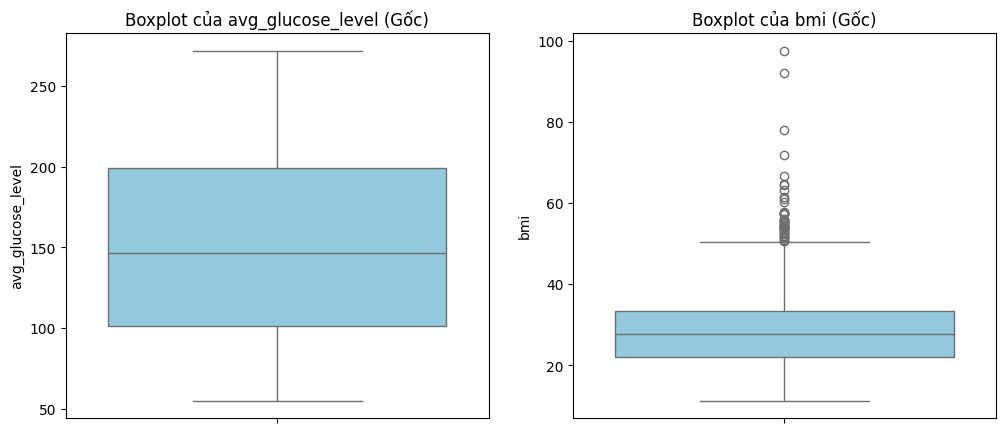

Thống kê mô tả trước khi xử lý:


,avg_glucose_level,bmi
count,42063.000000,42063.000000
mean,150.692319,27.746226
std,54.674398,7.136050
min,55.120000,11.300000
25%,101.315000,22.000000
50%,146.610000,27.700000
75%,198.955000,33.400000
max,271.740000,97.600000


In [12]:
# Load dữ liệu đã Impute (M2) từ bước trước
# Lưu ý: Chúng ta xử lý trên tập Train để dạy model, tập Test nên giữ nguyên hoặc chỉ kẹp giá trị
df_train = pd.read_csv('../data/processed/train_M2_knn.csv')

# ==========================================
# 2. TRỰC QUAN HÓA OUTLIER (BOXPLOT)
# ==========================================
numeric_cols = ['avg_glucose_level', 'bmi']

plt.figure(figsize=(12, 5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(y=df_train[col], color='skyblue')
    plt.title(f"Boxplot của {col} (Gốc)")
plt.show()

# Kiểm tra các giá trị cực hạn (Max/Min)
print("Thống kê mô tả trước khi xử lý:")
df_train[numeric_cols].describe()

### Outlier remove process

In [15]:
def cap_outliers_custom(df, col, lower_p=None, upper_p=None, hard_limits=None):
    """
    Hàm xử lý outlier linh hoạt:
    - Nếu dùng percentile (lower_p, upper_p): Kẹp theo phân phối dữ liệu.
    - Nếu dùng hard_limits (min, max): Kẹp theo kiến thức y khoa (Domain Knowledge).
    """
    df_clean = df.copy()
    series = df_clean[col]
    
    # 1. Xác định ngưỡng (Thresholds)
    if hard_limits:
        # Ưu tiên dùng ngưỡng cứng y khoa (nếu có)
        lower_limit, upper_limit = hard_limits
        method = "Hard Limit (Medical)"
    else:
        # Dùng thống kê (Percentile)
        lower_limit = series.quantile(lower_p) if lower_p else series.min()
        upper_limit = series.quantile(upper_p) if upper_p else series.max()
        method = f"Percentile ({lower_p}-{upper_p})"

    # In báo cáo
    print(f"\n--- Cột: {col} | Phương pháp: {method} ---")
    print(f"   Ngưỡng áp dụng: [{lower_limit:.2f}, {upper_limit:.2f}]")
    print(f"   Max value gốc: {series.max()}")
    
    # Đếm số lượng bị thay thế
    n_lower = (series < lower_limit).sum()
    n_upper = (series > upper_limit).sum()
    print(f"   Số lượng bị kẹp: {n_lower} (thấp) + {n_upper} (cao)")

    # 2. Thực hiện thay thế
    df_clean[col] = np.where(series > upper_limit, upper_limit,
                             np.where(series < lower_limit, lower_limit, series))
    return df_clean

In [17]:
# ==========================================
# 1. LOAD DATA (Kết quả từ bước KNN Imputation)
# ==========================================
# Đảm bảo bạn đã lưu file ở bước trước đó
try:
    df_train = pd.read_csv('../data/processed/train_M2_knn.csv')
    df_test = pd.read_csv('../data/processed/test_M2_knn.csv')
    print("✅ Đã load dữ liệu KNN thành công.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file dữ liệu đầu vào. Hãy kiểm tra lại folder data/processed/")

# ==========================================
# 2. TÍNH TOÁN NGƯỠNG (HỌC TỪ TRAIN)
# ==========================================l
# Chúng ta tính toán ngưỡng (limit) dựa trên phân phối của TRAIN set
print("\n--- Đang tính toán ngưỡng từ tập TRAIN ---")

# BMI: Lấy từ 1% đến 99% (Loại bỏ đuôi cực đoan > 41)
bmi_lower = df_train['bmi'].quantile(0.01)
bmi_upper = df_train['bmi'].quantile(0.99)
bmi_limits = (bmi_lower, bmi_upper)

# Glucose: Lấy từ 1% đến 99.5% (Giữ lại ca bệnh nặng, chỉ bỏ lỗi nhập liệu)
gluc_lower = df_train['avg_glucose_level'].quantile(0.01)
gluc_upper = df_train['avg_glucose_level'].quantile(0.995)
gluc_limits = (gluc_lower, gluc_upper)

print(f"Ngưỡng BMI học được: {bmi_limits}")
print(f"Ngưỡng Glucose học được: {gluc_limits}")

# ==========================================
# 3. ÁP DỤNG NGƯỠNG (CHO CẢ 2 TẬP)
# ==========================================

# --- A. Áp dụng cho TRAIN ---
print("\n>>> XỬ LÝ TẬP TRAIN")
df_train_clean = cap_outliers_custom(df_train, 'bmi', hard_limits=bmi_limits)
df_train_clean = cap_outliers_custom(df_train_clean, 'avg_glucose_level', hard_limits=gluc_limits)

# --- B. Áp dụng cho TEST (QUAN TRỌNG) ---
# Dùng chính ngưỡng bmi_limits, gluc_limits của Train để áp cho Test
print("\n>>> XỬ LÝ TẬP TEST")
df_test_clean = cap_outliers_custom(df_test, 'bmi', hard_limits=bmi_limits)
df_test_clean = cap_outliers_custom(df_test_clean, 'avg_glucose_level', hard_limits=gluc_limits)

# ==========================================
# 4. LƯU KẾT QUẢ
# ==========================================
# Lưu ra file riêng để dùng cho bước SMOTE (chỉ Train) và Validate (Test)
df_train_clean.to_csv('../data/processed/train_clean_final.csv', index=False)
df_test_clean.to_csv('../data/processed/test_clean_final.csv', index=False)

print("\n" + "="*40)
print("✅ HOÀN TẤT XỬ LÝ OUTLIER!")
print("File đã lưu:")
print("1. data/processed/train_clean_final.csv (Sẽ dùng để SMOTE)")
print("2. data/processed/test_clean_final.csv (Sẽ dùng để Test Model)")
print("="*40)

✅ Đã load dữ liệu KNN thành công.

--- Đang tính toán ngưỡng từ tập TRAIN ---
Ngưỡng BMI học được: (15.2, 41.0)
Ngưỡng Glucose học được: (62.0572, 249.03690000000003)

>>> XỬ LÝ TẬP TRAIN

--- Cột: bmi | Phương pháp: Hard Limit (Medical) ---
   Ngưỡng áp dụng: [15.20, 41.00]
   Max value gốc: 97.6
   Số lượng bị kẹp: 288 (thấp) + 418 (cao)

--- Cột: avg_glucose_level | Phương pháp: Hard Limit (Medical) ---
   Ngưỡng áp dụng: [62.06, 249.04]
   Max value gốc: 271.74
   Số lượng bị kẹp: 421 (thấp) + 211 (cao)

>>> XỬ LÝ TẬP TEST

--- Cột: bmi | Phương pháp: Hard Limit (Medical) ---
   Ngưỡng áp dụng: [15.20, 41.00]
   Max value gốc: 61.2
   Số lượng bị kẹp: 120 (thấp) + 182 (cao)

--- Cột: avg_glucose_level | Phương pháp: Hard Limit (Medical) ---
   Ngưỡng áp dụng: [62.06, 249.04]
   Max value gốc: 271.74
   Số lượng bị kẹp: 194 (thấp) + 100 (cao)

✅ HOÀN TẤT XỬ LÝ OUTLIER!
File đã lưu:
1. data/processed/train_clean_final.csv (Sẽ dùng để SMOTE)
2. data/processed/test_clean_final.csv (Sẽ 